---
## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

---
## 2. Paramètres physiques et de discrétisation

In [2]:
# Paramètres physiques
L   = 1.0    # longueur de la poutre [m]
E   = 1.0    # module d'Young [Pa]
rho = 1.0    # masse volumique [kg/m³]
I   = 1.0    # moment quadratique (sert pour la CL à droite)
v   = np.sqrt(E/rho)   # vitesse des ondes [m/s]

# Discrétisation
Nx    = 100    # points en espace
Nt    = 3000   # pas de temps internes (fin, pour la stabilité numérique)
t_end = 3      # durée de simulation [s]

dt_save = t_end / Nt
print(f"Δt entre snapshots sauvegardés : {dt_save:.5f} s")
print(f"Vitesse des ondes v = {v:.3f} m/s")

Δt entre snapshots sauvegardés : 0.00100 s
Vitesse des ondes v = 1.000 m/s


---
## 3. Espace des paramètres (A, ω)

On fait varier amplitude et pulsation pour que le modèle apprenne à généraliser.
Toutes les valeurs de ω doivent satisfaire $\lambda = 2\pi v / \omega < L$.

In [3]:
N = 3

AMPLITUDES = np.linspace(0.005, 0.1, N).round(3).tolist()
PULSATIONS = np.linspace(7, 90, N).round(1).tolist()


print(AMPLITUDES)
print(PULSATIONS)
# Vérification : la longueur d'onde doit être < L
omega_min_valid = 2 * np.pi * v / L
print(omega_min_valid)

for w in PULSATIONS:
    assert w > omega_min_valid, f"ω={w} invalide : longueur d'onde trop grande"

n_sims = len(AMPLITUDES) * len(PULSATIONS)
print(f"{len(AMPLITUDES)} amplitudes × {len(PULSATIONS)} pulsations = {n_sims} simulations")

[0.005, 0.052, 0.1]
[7.0, 48.5, 90.0]
6.283185307179586
3 amplitudes × 3 pulsations = 9 simulations


---
## 4. Fonction de simulation

In [24]:
def run_simulation(A_force, omega, E, I, rho, L, v=v, Nx=Nx, Nt=Nt, t_end=t_end):
    
    v     = np.sqrt(E/rho)    # vitesse des ondes [m/s]

    # Grille
    x  = np.linspace(0, L, Nx)
    dx = x[1] - x[0]
    dt = t_end / Nt

    # Stable behaviour
    CFL = v * dt / dx
    assert CFL <= 1.0, f"CFL={CFL:.3f} > 1 : schéma instable"

    # Conditions aux limites
    
    # The beam is clamped on the left side
    def u_left(t):
        return 0.0
    
    #A force is acting on the right side
    def du_dx_right(t):
        return (A_force * np.sin(omega * t))/(E*I)

    # Initial state, the entire beam is at rest
    u     = np.zeros(Nx)
    u_dot = np.zeros(Nx)

    rows = []

    # Timing loop
    for n in range(Nt):
        tn = n * dt

        # second derivative in space 
        u_xx = np.zeros(Nx)
        u_xx[1:-1] = (u[2:] - 2.0*u[1:-1] + u[:-2]) / dx**2

        # First derivative in time 
        u_dot_new = u_dot + dt * v**2 * u_xx

        # 2. Pas de Taylor ordre 2
        u_new     = u     + dt * u_dot + 0.5 * dt**2 * v**2 * u_xx

        # 3. Conditions aux limites
        u_new[0]  = u_left(tn)
        u_new[-1] = u_new[-2] + dx * du_dx_right(tn)

        # 4. Avancement
        u = u_new
        u_dot = u_dot_new

        # 5. Snapshot dans le dataset
        for j in range(1, Nx - 1):     # nœuds intérieurs
            rows.append({
                # --- Features : propriétés + position + temps ---
                "x"     : x[j],
                "L"     : L,
                "A"     : A_force,
                "E"     : E,
                "rho"   : rho,
                "omega" : omega,
                "I":I,
                "t"     : tn + dt,     # temps du déplacement enregistré
                
                # --- Target : déplacement à ce (x, t) ---
                "u"     : u[j],
            })

    return pd.DataFrame(rows)

---
## 5. Génération du dataset complet

In [25]:
all_dfs = []

# We compute each simulation
for idx, (A, w) in enumerate(product(AMPLITUDES, PULSATIONS), start=1):
    df_run = run_simulation(A_force=A, omega=w, E=E, I=I, rho=rho, L=L)
    all_dfs.append(df_run)

# We concatenate each simulation in the df which is the full dataset table
df = pd.concat(all_dfs, ignore_index=True)
print(df)

                x    L      A    E  rho  omega    I      t              u
0        0.010101  1.0  0.005  1.0  1.0    7.0  1.0  0.001       0.000000
1        0.020202  1.0  0.005  1.0  1.0    7.0  1.0  0.001       0.000000
2        0.030303  1.0  0.005  1.0  1.0    7.0  1.0  0.001       0.000000
3        0.040404  1.0  0.005  1.0  1.0    7.0  1.0  0.001       0.000000
4        0.050505  1.0  0.005  1.0  1.0    7.0  1.0  0.001       0.000000
...           ...  ...    ...  ...  ...    ...  ...    ...            ...
2645995  0.949495  1.0  0.100  1.0  1.0   90.0  1.0  3.000  634342.091960
2645996  0.959596  1.0  0.100  1.0  1.0   90.0  1.0  3.000 -493844.779539
2645997  0.969697  1.0  0.100  1.0  1.0   90.0  1.0  3.000  353239.109255
2645998  0.979798  1.0  0.100  1.0  1.0   90.0  1.0  3.000 -212529.897849
2645999  0.989899  1.0  0.100  1.0  1.0   90.0  1.0  3.000   71019.361778

[2646000 rows x 9 columns]


---
## 7. Split train / val / test

**Important** : on splitte par **combinaison (A, ω)**, pas par ligne.
Sinon le modèle mémorise les simulations au lieu d'apprendre la physique.

| Split | Fraction | Rôle |
|-------|----------|------|
| `train` | 70 % des simulations | Entraînement |
| `val`   | 15 % des simulations | Réglage des hyperparamètres |
| `test`  | 15 % des simulations | Évaluation finale |

In [26]:
rng = np.random.default_rng(seed=42)

combos     = list(product(AMPLITUDES, PULSATIONS))
combos_arr = rng.permutation(combos)

n_train = int(0.70 * n_sims)
n_val   = int(0.15 * n_sims)

train_combos = set(map(tuple, combos_arr[:n_train]))
val_combos   = set(map(tuple, combos_arr[n_train:n_train + n_val]))
test_combos  = set(map(tuple, combos_arr[n_train + n_val:]))

def assign_split(row):
    key = (row["A"], row["omega"])
    if key in train_combos: return "train"
    if key in val_combos:   return "val"
    return "test"

df["split"] = df.apply(assign_split, axis=1)

print("Distribution du split :")
for s in ["train", "val", "test"]:
    n = (df["split"] == s).sum()
    print(f"  {s:5s} : {n:>8,} lignes  ({100*n/len(df):.1f} %)")


Distribution du split :
  train : 1,764,000 lignes  (66.7 %)
  val   :  294,000 lignes  (11.1 %)
  test  :  588,000 lignes  (22.2 %)


---
## 8. Normalisation (z-score)

**Règle importante** : les statistiques (moyenne, écart-type) sont calculées
**uniquement sur le train set**, puis appliquées à val et test.
Si on calculait sur tout le dataset, on introduirait une fuite d'information.

On sauvegarde ces statistiques dans un fichier séparé — elles seront
nécessaires dans les fichiers d'entraînement et de validation.

In [27]:
INPUTS  = ["x", "L", "A", "E", "I", "rho", "omega", "t"]
OUTPUTS = ["u"]

# Masque train pour calculer les stats uniquement sur le train set
train_mask = df["split"] == "train"

# Calcul des stats sur le train set uniquement
norm_stats = pd.DataFrame({
    "mean": df.loc[train_mask, INPUTS + OUTPUTS].mean(),
    "std" : df.loc[train_mask, INPUTS + OUTPUTS].std(),
})
norm_stats["std"] = norm_stats["std"].replace(0, 1)  # éviter division par 0

# Application à tout le dataset
for col in INPUTS + OUTPUTS:
    df[col + "_n"] = (df[col] - norm_stats.loc[col, "mean"]) / norm_stats.loc[col, "std"]

print("Statistiques de normalisation (calculées sur train) :")
print(norm_stats.round(6))

Statistiques de normalisation (calculées sur train) :
            mean           std
x       0.500000      0.285744
L       1.000000      1.000000
A       0.052333      0.038784
E       1.000000      1.000000
I       1.000000      1.000000
rho     1.000000      1.000000
omega  34.666667     30.932282
t       1.500500      0.866026
u      -0.174758  48525.201510


---
## 9. Sauvegarde

In [28]:
COLS_ORDER = (
    INPUTS                                   # inputs bruts
    + [c + "_n" for c in INPUTS]             # inputs normalisés
    + OUTPUTS                                # outputs bruts
    + [c + "_n" for c in OUTPUTS]            # outputs normalisés
    + ["split"]
)
df = df[COLS_ORDER]

# Dataset
df.to_csv("wave_beam_dataset.csv", index=False)
print(f"Dataset sauvegardé : wave_beam_dataset.csv")
print(f"  {len(df):,} lignes × {len(df.columns)} colonnes")

# Stats de normalisation — à recharger dans les fichiers 2 et 3
norm_stats.to_csv("norm_stats.csv")
print(f"Stats de normalisation sauvegardées : norm_stats.csv")

Dataset sauvegardé : wave_beam_dataset.csv
  2,646,000 lignes × 19 colonnes
Stats de normalisation sauvegardées : norm_stats.csv


In [31]:
import json

params_simulation = {
    "L"          : L,
    "Nx"         : Nx,
    "Nt"         : Nt,
    "t_end"      : t_end,
    "I":I,
    "E": E,
    "rho":rho,
    "AMPLITUDES" : AMPLITUDES,
    "PULSATIONS" : PULSATIONS,
    "n_sims"     : n_sims,
}

with open("params_simulation.json", "w") as f:
    json.dump(params_simulation, f, indent=2)

print("Paramètres sauvegardés : params_simulation.json")

Paramètres sauvegardés : params_simulation.json


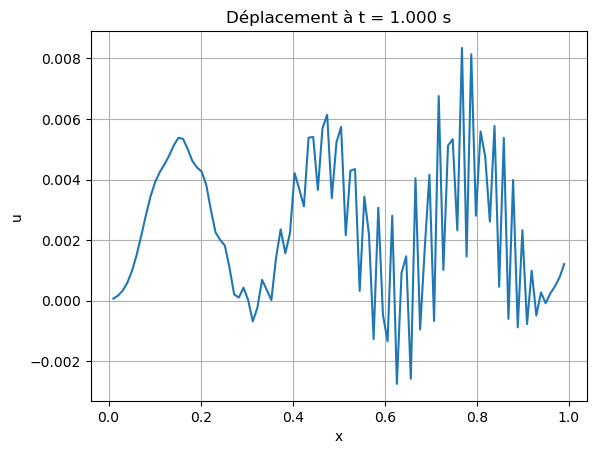

In [30]:
import matplotlib.pyplot as plt

t_target = 1.0

# /!\ on utilise df_plot pour ne pas écraser le dataset df
df_plot = run_simulation(A_force=0.05, omega=20.0, E=E, I=I, rho=rho, L=L)

t_closest = df_plot["t"].iloc[(df_plot["t"] - t_target).abs().argmin()]
snap = df_plot[df_plot["t"] == t_closest]

plt.plot(snap["x"], snap["u"])
plt.xlabel("x")
plt.ylabel("u")
plt.title(f"Déplacement à t = {t_closest:.3f} s")
plt.grid(True)
plt.show()